Below is a Q-learning model that is used to train an agent to regulate the temperature of a simulated simple environment with room size 50, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees.

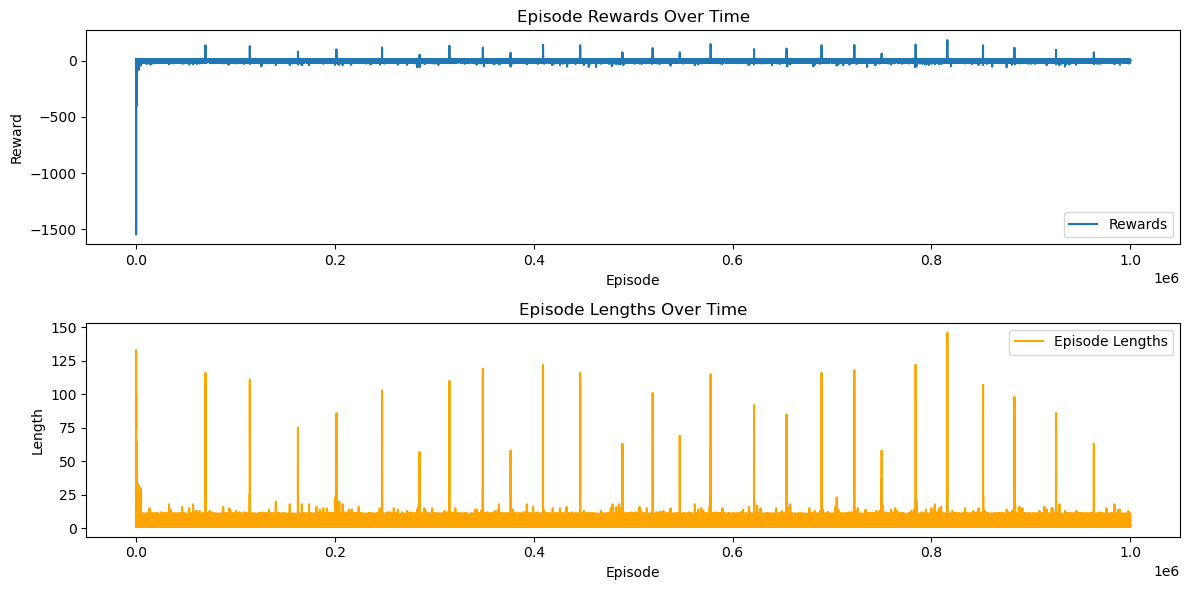

Q-table saved as an image at C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table.png
Training completed. Final Q-table:
[[32.6349906  37.58986849 39.46412301 53.58439782 34.14639707]
 [ 6.2898401  10.98032908 11.59428536 49.657324   14.46515072]
 [ 3.84139663  5.68416805  7.4459442  26.02993295  2.64795613]
 [36.63314306 42.524174   40.87897598 11.22863155 16.64233634]
 [37.44304516 41.99929339 48.49284229 14.06109752 16.55772811]
 [27.81698744 20.26273368 31.47891474 17.41629351  7.71760011]
 [ 5.47575235  5.46753052  1.3058286  17.41344815 -2.32127318]
 [ 6.3417703  43.84461391  0.98048251 -4.54245771 -4.61473363]
 [-0.47106745 30.88132608  0.49408705 -6.46873786 -8.69185534]
 [29.04377492  3.5470198   3.49996153 -5.30245929 -6.38571369]]
Aggregated Results:
Overall Average Reward: 7.16
Max Reward: 184.80
Min Reward: -1546.05
Average Episode Length: 1.57
Max Episode Length: 146.00
Min Episode Length: 1.00


In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os


#Defining the model learning parameters
class QLearning:
    def __init__(self, state_space_size, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.1):
        self.q_table = np.zeros((state_space_size, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(range(self.q_table.shape[1]))  # Line of action for exploration.
        else:
            return np.argmax(self.q_table[state])  # Line of action for exploitation.

    def update_q_table(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

#Simulating the environment
class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.temp_bins = np.linspace(15, 30, 10)  # The temperature was separated into bins of 10 using this line

    def discretize_state(self, temp):
        if temp < self.temp_bins[0]:
            return 0
        elif temp > self.temp_bins[-1]:
            return len(self.temp_bins) - 1
        return np.digitize(temp, self.temp_bins) - 1 

    def step(self, action):
        action = max(0, min(action, 4))  # This line is for making sure the action is within range
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        # Reward function is being updated, giving a bonus for getting close to the target temperature, medium reward for a deviation greater than 0.5 but less than 1 degree, and a negative reward proportional to the deviation when the deviation is greater than 1 degree
        deviation = abs(self.current_temp - 22)
        if deviation < 0.5:
            reward = 10 
        elif deviation < 1.0:
            reward = 5  
        else:
            reward = -min(deviation, 20) 
        
        discrete_state = self.discretize_state(self.current_temp)
        return discrete_state, reward

# Defining the environment and the agent
env = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)
agent = QLearning(state_space_size=10, action_space_size=5, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01)

episode_rewards = []
episode_lengths = []

# The section below is the training loop for the agent.
num_episodes = 1000000  # 1000000 episodes was used to train this agent
for episode in range(num_episodes):
    state = env.discretize_state(env.current_temp)
    total_reward = 0
    length = 0
    done = False
    while not done:
        action = agent.choose_action(state)
        next_state, reward = env.step(action)
        agent.update_q_table(state, action, reward, next_state)
        state = next_state
        total_reward += reward
        length += 1
        if abs(env.current_temp - 22) < 0.5:  
            done = True
    agent.decay_epsilon()  # Epsilon was set to decay over time with this line of code
    episode_rewards.append(total_reward)
    episode_lengths.append(length)

# This section was used to visualize the results obtained from this model
plt.figure(figsize=(12, 6))

# The code for plotting the episode reward result
plt.subplot(2, 1, 1)
plt.plot(episode_rewards, label='Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Episode Rewards Over Time')
plt.legend()

# The code for plotting the episode length result
plt.subplot(2, 1, 2)
plt.plot(episode_lengths, label='Episode Lengths', color='orange')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.title('Episode Lengths Over Time')
plt.legend()

plt.tight_layout()
plt.show()

# The code for saving the q-table from this Q-learning model
q_table_image_path = r"C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table.png"
plt.figure(figsize=(10, 8))
sns.heatmap(agent.q_table, annot=True, fmt=".2f", cmap='viridis')
plt.title('Q-Table Heatmap')
plt.xlabel('Actions')
plt.ylabel('States')
plt.savefig(q_table_image_path)
plt.close()

print(f"Q-table saved as an image at {q_table_image_path}")

# The results are being printed using this
print("Training completed. Final Q-table:")
print(agent.q_table)

print("Aggregated Results:")
print(f"Overall Average Reward: {np.mean(episode_rewards):.2f}")
print(f"Max Reward: {np.max(episode_rewards):.2f}")
print(f"Min Reward: {np.min(episode_rewards):.2f}")
print(f"Average Episode Length: {np.mean(episode_lengths):.2f}")
print(f"Max Episode Length: {np.max(episode_lengths):.2f}")
print(f"Min Episode Length: {np.min(episode_lengths):.2f}")


Below is a Q-learning model that is used to train an agent to regulate the temperature of a simulated simple environment with room size 50, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees. Although, for this model, three different exploration strategies (epsilon-greedy, SoftMax, and UCB) will be experimented to investigate the effect of different exploration-exploitation strategies in Q-learning models with complex environment dynamics.

Epsilon-Greedy Statistics: {'average_reward': 7.152120854978178, 'max_reward': 168.58048053191553, 'min_reward': -1096.038286646378, 'average_length': 1.560168, 'max_length': 187, 'min_length': 1}
Softmax Statistics: {'average_reward': 9.862819505710698, 'max_reward': 23.219415322148755, 'min_reward': -347.88346044559756, 'average_length': 4.133284, 'max_length': 56, 'min_length': 1}
UCB Statistics: {'average_reward': 7.267666108713659, 'max_reward': 10.0, 'min_reward': -419.434502692735, 'average_length': 3.500571, 'max_length': 71, 'min_length': 1}


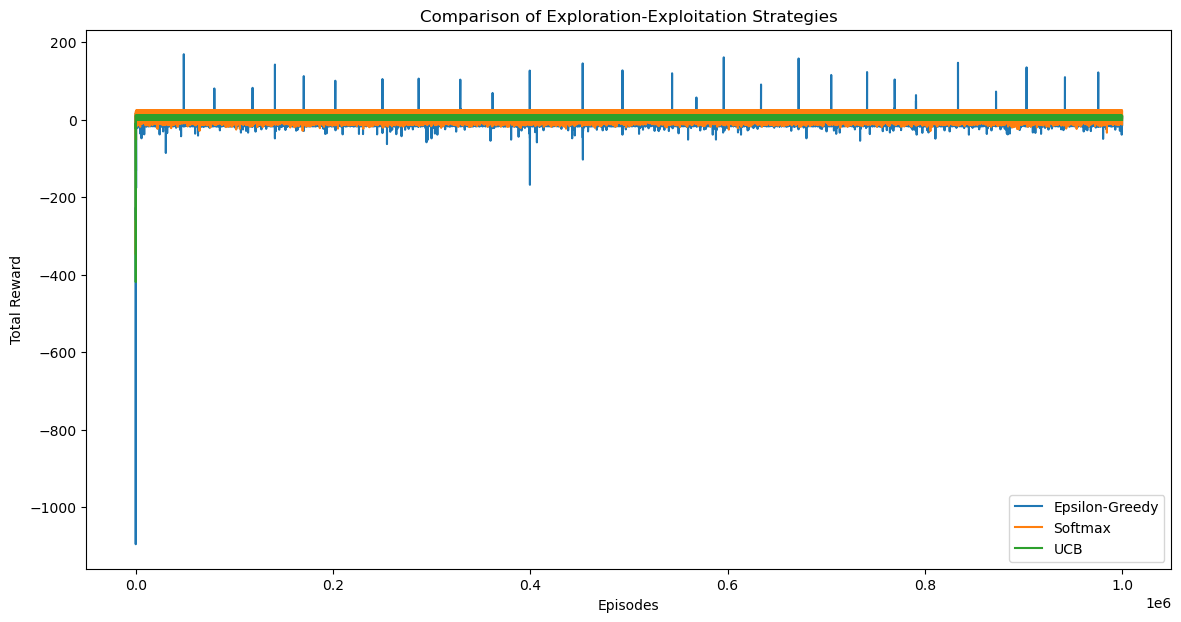

Q-tables saved as images at C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_epsilon.png, C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_softmax.png, and C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_ucb.png
Training completed. Final Q-tables:
Epsilon-Greedy Q-table:
[[ 31.98104854  37.15642764  38.87225079  52.24145906  34.0223641 ]
 [  8.36038696  20.18352046  10.0473007   48.63654954  16.2587058 ]
 [ -2.03053799  -0.87017873   0.6276821   30.56992375  -1.97012698]
 [ 34.81984533  41.78136193  37.76763613  28.29087369  22.66705558]
 [ 36.77978678  41.60237801  47.98445206  28.28813185  22.38170087]
 [  2.92631384   9.00658854  36.0352082    2.30826078  -2.82760306]
 [  9.61917617  36.36575931   6.48894043   1.81773889  -2.6559052 ]
 [  6.31503275  42.95235567   0.96491187  -4.80587285  -8.00356125]
 [ -0.22847093  19.12322921  -0.99448991  -5.76227362 -12.02475441]
 [ 35.47577668   3.69396539   0.83027109  -4.6224282

In [1]:
#Exploration and exploitation strategies for Q-learning

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Defining the model learning parameters
class QLearning:
    def __init__(self, state_space_size, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.1):
        self.q_table = np.zeros((state_space_size, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.visit_counts = np.zeros((state_space_size, action_space_size))  # This line is used to track the visits for UCB

    def choose_action_epsilon(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(range(self.q_table.shape[1]))  # Exploration line
        else:
            return np.argmax(self.q_table[state])  # Exploitation line

    def choose_action_softmax(self, state):
        q_values = self.q_table[state]
        exp_q = np.exp(q_values - np.max(q_values))  # It helps to avoid overflow
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(range(self.q_table.shape[1]), p=probs)

    def choose_action_ucb(self, state, step):
        if np.any(self.visit_counts[state] == 0):
            return np.random.choice(range(self.q_table.shape[1]))  # For Exploring unvisited actions
        
        total_visits = np.sum(self.visit_counts[state])
        action_visits = self.visit_counts[state]
        q_values = self.q_table[state]

        ucb_values = q_values + np.sqrt(2 * np.log(total_visits + 1) / (action_visits + 1))
        return np.argmax(ucb_values)

    def update_q_table(self, state, action, reward, next_state):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error
        self.visit_counts[state][action] += 1  # For updating the visit count for UCB

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.temp_bins = np.linspace(15, 30, 10)  

    def discretize_state(self, temp):
        if temp < self.temp_bins[0]:
            return 0
        elif temp > self.temp_bins[-1]:
            return len(self.temp_bins) - 1
        return np.digitize(temp, self.temp_bins) - 1  

    def step(self, action):
        action = max(0, min(action, 4))  # Helps to ensure action is within range
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        # Updated reward function
        deviation = abs(self.current_temp - 22)
        if deviation < 0.5:
            reward = 10  
        elif deviation < 1.0:
            reward = 5   
        else:
            reward = -min(deviation, 20)  
        
        discrete_state = self.discretize_state(self.current_temp)
        return discrete_state, reward

def train_agent(agent, strategy, env, num_episodes):
    episode_rewards = []
    episode_lengths = []

    for episode in range(num_episodes):
        state = env.discretize_state(env.current_temp)
        total_reward = 0
        length = 0
        done = False
        while not done:
            if strategy == 'epsilon':
                action = agent.choose_action_epsilon(state)
            elif strategy == 'softmax':
                action = agent.choose_action_softmax(state)
            elif strategy == 'ucb':
                action = agent.choose_action_ucb(state, episode)
                
            next_state, reward = env.step(action)
            agent.update_q_table(state, action, reward, next_state)
            state = next_state
            total_reward += reward
            length += 1
            if abs(env.current_temp - 22) < 0.5:  
                done = True
        agent.decay_epsilon()  # Decay epsilon over time for epsilon-based strategy
        episode_rewards.append(total_reward)
        episode_lengths.append(length)

    return episode_rewards, episode_lengths

def calculate_statistics(rewards, lengths):
    return {
        "average_reward": np.mean(rewards),
        "max_reward": np.max(rewards),
        "min_reward": np.min(rewards),
        "average_length": np.mean(lengths),
        "max_length": np.max(lengths),
        "min_length": np.min(lengths)
    }

def plot_comparison(rewards_epsilon, rewards_softmax, rewards_ucb, num_episodes):
    episodes = range(num_episodes)
    plt.figure(figsize=(14, 7))
    
    plt.plot(episodes, rewards_epsilon, label='Epsilon-Greedy')
    plt.plot(episodes, rewards_softmax, label='Softmax')
    plt.plot(episodes, rewards_ucb, label='UCB')
    
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title('Comparison of Exploration-Exploitation Strategies')
    plt.legend()
    plt.show()

def save_q_table_image(q_table, path):
    plt.figure(figsize=(10, 8))
    sns.heatmap(q_table, annot=True, fmt=".2f", cmap='viridis')
    plt.title('Q-Table Heatmap')
    plt.xlabel('Actions')
    plt.ylabel('States')
    plt.savefig(path)
    plt.close()

# Definining the environment and agents
env = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)

agent_epsilon = QLearning(state_space_size=10, action_space_size=5, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01)
agent_softmax = QLearning(state_space_size=10, action_space_size=5, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01)
agent_ucb = QLearning(state_space_size=10, action_space_size=5, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01)

# Code for Training agents
num_episodes = 1000000
rewards_epsilon, lengths_epsilon = train_agent(agent_epsilon, 'epsilon', env, num_episodes)
rewards_softmax, lengths_softmax = train_agent(agent_softmax, 'softmax', env, num_episodes)
rewards_ucb, lengths_ucb = train_agent(agent_ucb, 'ucb', env, num_episodes)

# Calculating statistics
stats_epsilon = calculate_statistics(rewards_epsilon, lengths_epsilon)
stats_softmax = calculate_statistics(rewards_softmax, lengths_softmax)
stats_ucb = calculate_statistics(rewards_ucb, lengths_ucb)

print("Epsilon-Greedy Statistics:", stats_epsilon)
print("Softmax Statistics:", stats_softmax)
print("UCB Statistics:", stats_ucb)

# Plotting the results
plot_comparison(rewards_epsilon, rewards_softmax, rewards_ucb, num_episodes)

# Saving the Q-tables as images
q_table_epsilon_path = r"C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_epsilon.png"
q_table_softmax_path = r"C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_softmax.png"
q_table_ucb_path = r"C:\Users\presi\Downloads\Dissertation2024\Dissertation Images\q_table_ucb.png"

save_q_table_image(agent_epsilon.q_table, q_table_epsilon_path)
save_q_table_image(agent_softmax.q_table, q_table_softmax_path)
save_q_table_image(agent_ucb.q_table, q_table_ucb_path)

print(f"Q-tables saved as images at {q_table_epsilon_path}, {q_table_softmax_path}, and {q_table_ucb_path}")

# Printing the final Q-tables and aggregated results
print("Training completed. Final Q-tables:")
print("Epsilon-Greedy Q-table:")
print(agent_epsilon.q_table)
print("Softmax Q-table:")
print(agent_softmax.q_table)
print("UCB Q-table:")
print(agent_ucb.q_table)

print("Aggregated Results:")
print("Epsilon-Greedy:")
print(stats_epsilon)
print("Softmax:")
print(stats_softmax)
print("UCB:")
print(stats_ucb)


Below is a Q-learning model that is used to train an agent to regulate the temperature of a simulated environment with randomly changing occupancy status, room size of 50m2, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees.

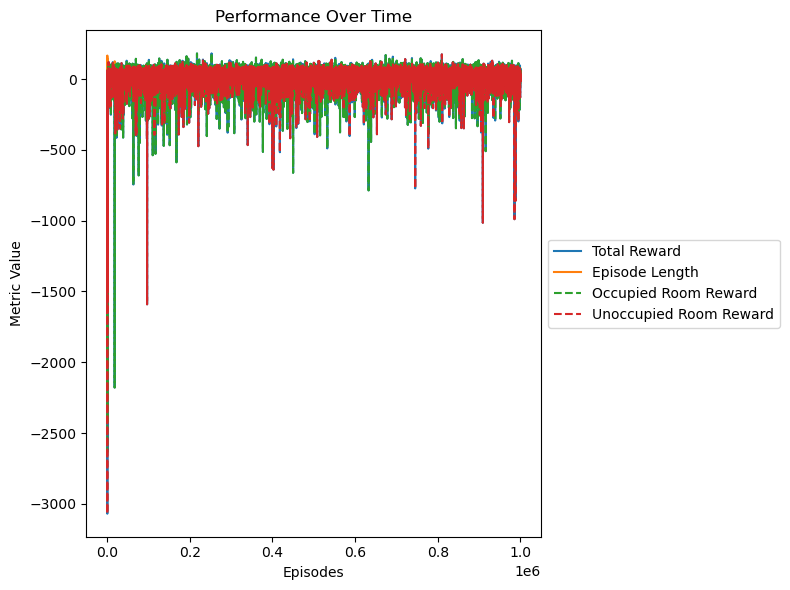

Overall Statistics: {'average_reward': 14.602339443774305, 'max_reward': 181.60093152967707, 'min_reward': -3069.7759166907404, 'average_length': 4.668389, 'max_length': 166, 'min_length': 1}
Occupied Room Statistics: {'average_reward': 14.371118768168762, 'max_reward': 181.60093152967707, 'min_reward': -2633.865182028062, 'average_length': 4.540966467263048, 'max_length': 145, 'min_length': 1}
Unoccupied Room Statistics: {'average_reward': 15.223828148628815, 'max_reward': 174.67651716182883, 'min_reward': -3069.7759166907404, 'average_length': 5.010882873580174, 'max_length': 166, 'min_length': 1}


In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import os

#Defining the model learning parameters
class QLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.1, replay_size=10000, batch_size=32):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table = np.zeros((*state_space_dims, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size

#In this part if the code, acyions were defined for when the room was occupied and non occupied, aggressive actions were limited for unoccupied rooms, and extreme actions were avoided
    def choose_action(self, state, occupancy_status):
        if random.uniform(0, 1) < self.epsilon:
            if occupancy_status == 0:  
                return random.choice([1, 2, 3])  
            else:
                return random.choice(range(self.action_space_size))  
        else:
            return np.argmax(self.q_table[state])  

    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        if len(self.memory) >= self.batch_size:
            self.replay_experience()

    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            best_next_action = np.argmax(self.q_table[next_state])
            td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
            td_error = td_target - self.q_table[state][action]
            self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self, occupancy_status):
        # Epsilon was made to decay more aggresively to give opportunity for more exploitation
        decay_rate = 0.998 if occupancy_status == 0 else self.epsilon_decay
        self.epsilon = max(self.min_epsilon, self.epsilon * decay_rate)

#Simulating the environment, by creating a bin for the temerature, occupancy status, and time. This was important as it was a cylic process that meant training for each hour of the day and the occupancy status varied according to the time of the day
class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.time_of_day = 0  
        self.occupancy_status = 1  
        self.temp_bins = np.linspace(15, 30, 10)  
        self.time_bins = np.linspace(0, 23, 24)  

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))  # This line if the code was to ensure that the action was within range
        
        # The impact of the actions taken was limited when the room was unoccupied
        if self.occupancy_status == 0:  
            temp_change = (self.hvac_power * 0.5 * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        else:  # In occupied rooms the operations went on as normal
            temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        
        self.current_temp += temp_change
        
        # Clarifying that there are two different target temperatures based on whether the room is occupied or unoccupied
        target_temp = 22 if self.occupancy_status == 1 else 18  
        deviation = abs(self.current_temp - target_temp)
        
        # This part of this code was added to avoid extreme negative rewards, and the positive rewards for moving close to the target temperature.
        if deviation < 0.5:
            reward = 10 
        elif deviation < 1.0:
            reward = 5   
        else:
            reward = -min(deviation, 20)  
        
        # The penalties for the unoccupied room is defined separately
        if self.occupancy_status == 0:
            reward -= abs(action - 2)  #
        
        
        reward = np.clip(reward, -50, 50)

        # This is the part of the code that was used to update the time of the day and occupancy status in this project.
        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

# Defininig the environment and agent
state_space_dims = (10, 24, 2) 
action_space_size = 5
agent = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)

env = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)

episode_rewards = []
episode_lengths = []


occupied_rewards = []
unoccupied_rewards = []
occupied_lengths = []
unoccupied_lengths = []
occupied_indices = []  
unoccupied_indices = []  

# # The section below is the training loop for the agent
num_episodes = 1000000  # This training was done over 1,000,000 episodes
for episode in range(num_episodes):
    state = env.discretize_state()
    total_reward = 0
    length = 0
    done = False
    while not done:
        action = agent.choose_action(state, env.occupancy_status)
        next_state, reward = env.step(action)
        agent.update_q_table(state, action, reward, next_state)
        state = next_state
        total_reward += reward
        length += 1
        if abs(env.current_temp - (22 if env.occupancy_status == 1 else 18)) < 0.5:  
            done = True
    agent.decay_epsilon(env.occupancy_status)  # The epsilon decay for this model kept getting adjusted based on whether there were occupants or not in the room 
    
    episode_rewards.append(total_reward)
    episode_lengths.append(length)
    
    # This is where the reward is being tracked
    if env.occupancy_status == 1:
        occupied_rewards.append(total_reward)
        occupied_lengths.append(length)
        occupied_indices.append(episode)  
    else:
        unoccupied_rewards.append(total_reward)
        unoccupied_lengths.append(length)
        unoccupied_indices.append(episode)

# The statistics of this model was cakcukate
def calculate_statistics(rewards, lengths):
    return {
        "average_reward": np.mean(rewards),
        "max_reward": np.max(rewards),
        "min_reward": np.min(rewards),
        "average_length": np.mean(lengths),
        "max_length": np.max(lengths),
        "min_length": np.min(lengths)
    }

# All the results fuction were printed out at the end of this training.
def plot_results(episodes, episode_rewards, episode_lengths, occupied_indices, occupied_rewards, unoccupied_indices, unoccupied_rewards):
    plt.figure(figsize=(10, 6))
    

    plt.plot(episodes, episode_rewards, label='Total Reward')
    plt.plot(episodes, episode_lengths, label='Episode Length')
    

    plt.plot(occupied_indices, occupied_rewards, label='Occupied Room Reward', linestyle='--')
    plt.plot(unoccupied_indices, unoccupied_rewards, label='Unoccupied Room Reward', linestyle='--')
    
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    plt.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.xlabel('Episodes')
    plt.ylabel('Metric Value')
    plt.title('Performance Over Time')
    
    plt.tight_layout(rect=[0, 0, 0.8, 1])

    plt.show()


episodes = list(range(num_episodes))
plot_results(episodes, episode_rewards, episode_lengths, occupied_indices, occupied_rewards, unoccupied_indices, unoccupied_rewards)

print("Overall Statistics:", calculate_statistics(episode_rewards, episode_lengths))
print("Occupied Room Statistics:", calculate_statistics(occupied_rewards, occupied_lengths))
print("Unoccupied Room Statistics:", calculate_statistics(unoccupied_rewards, unoccupied_lengths))


Below is a Q-learning model that is used to train an agent to regulate the temperature of a simulated environment with randomly changing occupancy status, room size of 50m2, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees. Although, for this model, three different exploration strategies (epsilon-greedy, SoftMax, and UCB) will be experimented to investigate the effect of different exploration-exploitation strategies in Q-learning models with complex environment dynamics.

Epsilon-Greedy Statistics: {'average_reward': 5.503318411244372, 'max_reward': 157.57302207872428, 'min_reward': -3335.4483131077827, 'average_length': 5.6317, 'max_length': 231, 'min_length': 1}
Softmax Statistics: {'average_reward': 12.157822538400064, 'max_reward': 139.30635705589805, 'min_reward': -1805.3264302458433, 'average_length': 5.1344, 'max_length': 147, 'min_length': 1}
UCB Statistics: {'average_reward': 7.996111564615354, 'max_reward': 185.16092329910202, 'min_reward': -2402.8234746411986, 'average_length': 5.2542, 'max_length': 196, 'min_length': 1}


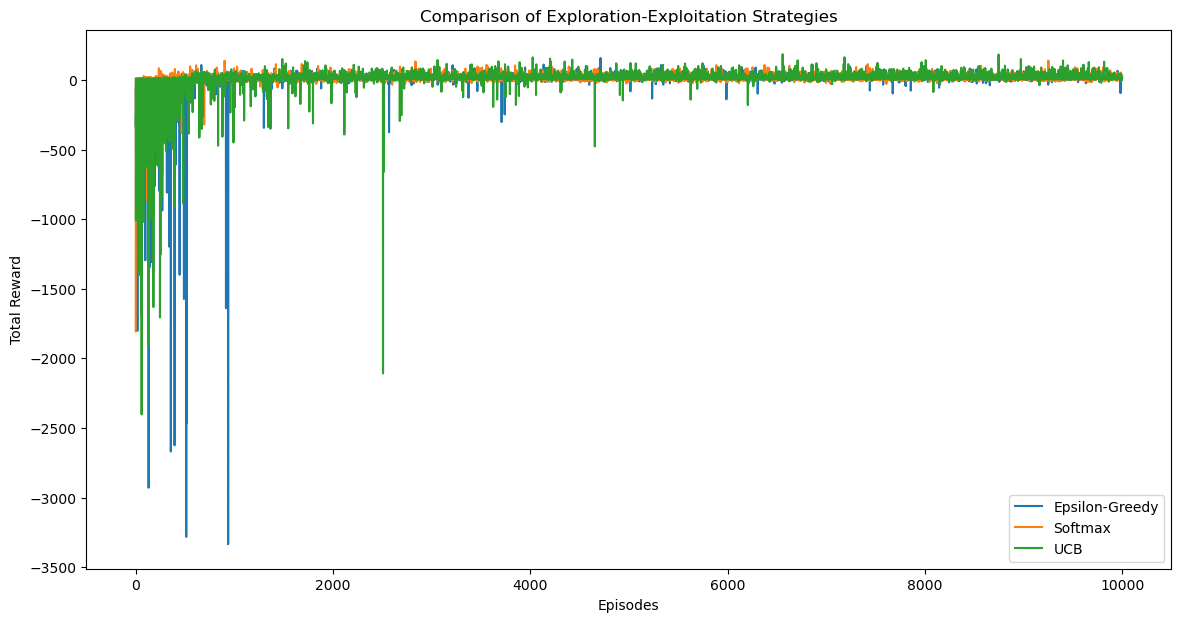

In [21]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

class QLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.99, min_epsilon=0.1, replay_size=10000, batch_size=32):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table = np.zeros((*state_space_dims, action_space_size))
        self.visit_counts = np.zeros((*state_space_dims, action_space_size))  # This line is used to track the visits for UCB
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size

    def choose_action(self, state, occupancy_status):
        if random.uniform(0, 1) < self.epsilon:
            if occupancy_status == 0:  # In unoccupied rooms, the agent avoids taking aggressive actions, and explores normally in occupied rooms.
                return random.choice([1, 2, 3])  
            else:
                return random.choice(range(self.action_space_size))  
        else:
            return np.argmax(self.q_table[state])  # This line performs exploitation

    def choose_action_softmax(self, state):
        q_values = self.q_table[state]
        exp_q = np.exp(q_values - np.max(q_values))  # This line on code helps to avoid overflow
        probs = exp_q / np.sum(exp_q)
        return np.random.choice(range(self.action_space_size), p=probs)

    def choose_action_ucb(self, state, step):
        if np.any(self.visit_counts[state] == 0):
            return np.random.choice(range(self.action_space_size))  # This line of code is used to explore the unvisited actions using UCB strategy

        total_visits = np.sum(self.visit_counts[state])  # This is where the record of the sum of all visited actions are kept and summed up
        action_visits = self.visit_counts[state]  # This is the line that stores the number of times actions are visited
        q_values = self.q_table[state]  

        ucb_values = q_values + np.sqrt(2 * np.log(total_visits + 1) / (action_visits + 1))
        return np.argmax(ucb_values)

    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        self.visit_counts[state][action] += 1  # This line Updates the visit count for UCB
        if len(self.memory) >= self.batch_size:
            self.replay_experience()

    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            best_next_action = np.argmax(self.q_table[next_state])
            td_target = reward + self.gamma * self.q_table[next_state][best_next_action]
            td_error = td_target - self.q_table[state][action]
            self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self, occupancy_status):
        decay_rate = 0.998 if occupancy_status == 0 else self.epsilon_decay
        self.epsilon = max(self.min_epsilon, self.epsilon * decay_rate)

class HVACEnvironment:
    def __init__(self, room_size, insulation, external_temp, hvac_power):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.time_of_day = 0  
        self.occupancy_status = 1  # 1 in this line of code indicates that the room is occupied
        self.temp_bins = np.linspace(15, 30, 10)  # This line create bins for temperature ranging from 15 - 30 degrees
        self.time_bins = np.linspace(0, 23, 24)  # This line creates bins for each hour of the day

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))  # Ensuring the action is within range
        
        # In this part of the code, the impact of the actions is limited
        if self.occupancy_status == 0:  # In unoccupied rooms large temperature shifts are avoided
            temp_change = (self.hvac_power * 0.5 * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        else:  # Occupied, normal operation
            temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        
        self.current_temp += temp_change
        
        # This line sets separate penalty rules for when the room is occupied and unoccupied
        target_temp = 22 if self.occupancy_status == 1 else 18  
        deviation = abs(self.current_temp - target_temp)
        
        # This part if the code is used to set a lower cap on penalties
        if deviation < 0.5:
            reward = 10  
        elif deviation < 1.0:
            reward = 5   
        else:
            reward = -min(deviation, 20)  
        
        #This part of the code penalizes stronger HVAC actions
        if self.occupancy_status == 0:
            reward -= abs(action - 2)  
        
        # There was a cap put on extreme penalties
        reward = np.clip(reward, -50, 50)

        # The time of the day and the random occupancy changes are being updated using this part of the code
        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

def train_agent(agent, strategy, env, num_episodes):
    episode_rewards = []
    episode_lengths = []
    
    for episode in range(num_episodes):
        state = env.discretize_state()
        total_reward = 0
        length = 0
        done = False
        while not done:
            if strategy == 'epsilon':
                action = agent.choose_action(state, env.occupancy_status)
            elif strategy == 'softmax':
                action = agent.choose_action_softmax(state)
            elif strategy == 'ucb':
                action = agent.choose_action_ucb(state, episode)
                
            next_state, reward = env.step(action)
            agent.update_q_table(state, action, reward, next_state)
            state = next_state
            total_reward += reward
            length += 1
            if abs(env.current_temp - (22 if env.occupancy_status == 1 else 18)) < 0.5:
                done = True
        agent.decay_epsilon(env.occupancy_status)  
        
        episode_rewards.append(total_reward)
        episode_lengths.append(length)
    
    return episode_rewards, episode_lengths

def calculate_statistics(rewards, lengths):
    return {
        "average_reward": np.mean(rewards),
        "max_reward": np.max(rewards),
        "min_reward": np.min(rewards),
        "average_length": np.mean(lengths),
        "max_length": np.max(lengths),
        "min_length": np.min(lengths)
    }

def plot_comparison(rewards_epsilon, rewards_softmax, rewards_ucb, num_episodes):
    episodes = range(num_episodes)
    plt.figure(figsize=(14, 7))
    
    plt.plot(episodes, rewards_epsilon, label='Epsilon-Greedy')
    plt.plot(episodes, rewards_softmax, label='Softmax')
    plt.plot(episodes, rewards_ucb, label='UCB')
    
    plt.xlabel('Episodes')
    plt.ylabel('Total Reward')
    plt.title('Comparison of Exploration-Exploitation Strategies')
    plt.legend()
    plt.show()

# Defining the environments and the agents
state_space_dims = (10, 24, 2)  # This represents the temperature bins, time bins, and occupancy status
action_space_size = 5
num_episodes = 10000

# Initializing the environments
env = HVACEnvironment(room_size=50, insulation=0.1, external_temp=20, hvac_power=5)

# Initializing the agents
agent_epsilon = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)
agent_softmax = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)
agent_ucb = QLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)

# Training the agents
rewards_epsilon, lengths_epsilon = train_agent(agent_epsilon, 'epsilon', env, num_episodes)
rewards_softmax, lengths_softmax = train_agent(agent_softmax, 'softmax', env, num_episodes)
rewards_ucb, lengths_ucb = train_agent(agent_ucb, 'ucb', env, num_episodes)

# Calculating the statistics
stats_epsilon = calculate_statistics(rewards_epsilon, lengths_epsilon)
stats_softmax = calculate_statistics(rewards_softmax, lengths_softmax)
stats_ucb = calculate_statistics(rewards_ucb, lengths_ucb)

print("Epsilon-Greedy Statistics:", stats_epsilon)
print("Softmax Statistics:", stats_softmax)
print("UCB Statistics:", stats_ucb)

# Plotting the results
plot_comparison(rewards_epsilon, rewards_softmax, rewards_ucb, num_episodes)


Below is a Double Q-learning model that is used to train an agent to regulate the temperature of a simulated environment with randomly changing occupancy status, room size of 50m2, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees for when the rrom was occupied, and 18 degrees for when the room was unoccupied. This model was trained to investigate how effectively temperature control can be in extreme weather conditions like winter and summer

Saved: C:\Users\presi\Downloads\Dissertation2024\winter_average_q_tableQ1_occupancy_0.png
Saved: C:\Users\presi\Downloads\Dissertation2024\winter_average_q_tableQ1_occupancy_1.png
Saved: C:\Users\presi\Downloads\Dissertation2024\winter_average_q_tableQ2_occupancy_0.png
Saved: C:\Users\presi\Downloads\Dissertation2024\winter_average_q_tableQ2_occupancy_1.png
Saved: C:\Users\presi\Downloads\Dissertation2024\summer_average_q_tableQ1_occupancy_0.png
Saved: C:\Users\presi\Downloads\Dissertation2024\summer_average_q_tableQ1_occupancy_1.png
Saved: C:\Users\presi\Downloads\Dissertation2024\summer_average_q_tableQ2_occupancy_0.png
Saved: C:\Users\presi\Downloads\Dissertation2024\summer_average_q_tableQ2_occupancy_1.png


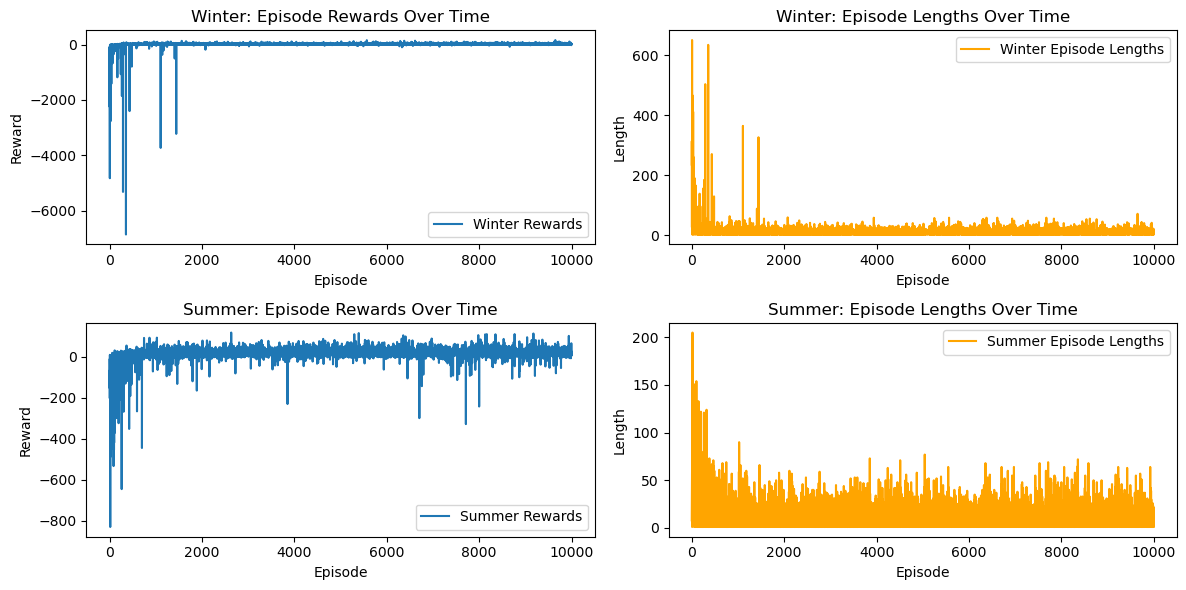

Winter Training Completed. Final Q-table:
[[[[-9.49980954e+00 -6.13119770e+00  0.00000000e+00  3.14051619e+01
     0.00000000e+00]
   [-1.21712255e+01 -9.99947989e+00 -1.47266703e+01  2.18854078e+01
     2.05265734e+00]]

  [[-1.42359981e+01  2.67155126e+00  2.53078204e-01  2.80418584e+01
     1.78956738e+01]
   [-2.73754513e+00  5.27041713e-01  1.84925373e-02  1.76480479e+01
     2.32550299e+01]]

  [[-1.16937515e+01 -1.31706661e+01 -7.53644787e+00  2.82153302e+01
     5.44103692e+00]
   [-1.11682683e+01 -8.71301809e+00 -7.78112587e+00  2.47838607e+01
     6.45947089e+00]]

  ...

  [[ 5.73004377e+00  0.00000000e+00 -9.50879484e+00  0.00000000e+00
     1.99978206e+01]
   [-1.33647729e+01  7.06028578e+00 -1.09960834e+01  4.61903760e+00
     2.00143391e+01]]

  [[-7.38181987e+00 -8.00385543e+00 -7.14342439e+00  3.04755602e+01
     4.24458602e+00]
   [-1.16760380e+01  4.46694028e+00  1.36858716e+01  2.01888657e+01
     0.00000000e+00]]

  [[-6.93851092e+00 -6.93299286e+00 -7.09822909e+00

In [8]:

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import seaborn as sns
import os

# Deffining the HVAC Environment
class HVACEnvironment:
    def __init__(self, room_size, insulation, hvac_power, external_temp):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.time_of_day = 0
        self.occupancy_status = 1
        self.temp_bins = np.linspace(15, 30, 10)
        self.time_bins = np.linspace(0, 23, 24)

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        target_temp = 22 if self.occupancy_status == 1 else 18
        deviation = abs(self.current_temp - target_temp)
        
        # The reward function in this model was designed in a way to reduce the penalty for deviations beyond 1.0 degree as opposed to the other models that had larger penalties for deviations beyond 1.0 degree
        if deviation < 0.5:
            reward = 10
        elif deviation < 1.0:
            reward = 5
        else:
            reward = -0.25 * (deviation - 1)

        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

class DoubleQLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table1 = np.zeros((*state_space_dims, action_space_size))
        self.q_table2 = np.zeros((*state_space_dims, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(range(self.action_space_size))  # This line of the code tells the model to explore
        else:
            q_values = (self.q_table1[state] + self.q_table2[state]) / 2
            return np.argmax(q_values)  # This line of the code tells the model to exploit when not exploring

    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        if len(self.memory) >= self.batch_size:
            self.replay_experience()

#Double Q-learning works by using 2 Q-tables, it chooses actions from Q-table 1 and computes the target using Q-table 2, and the way it chooses actions from Q-table 2 and  computes the target using Q-table 1
    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            # This line is designed to Choose actions from Q-table 1
            best_action = np.argmax(self.q_table1[next_state])
            # This line is designed to Compute targets using Q-table 2
            td_target = reward + self.gamma * self.q_table2[next_state][best_action]
            td_error = td_target - self.q_table1[state][action]
            self.q_table1[state][action] += self.alpha * td_error
            
            # This line is designed to Choose action from Q-table 2
            best_action = np.argmax(self.q_table2[next_state])
            # This line is designed to Compute target using Q-table 1
            td_target = reward + self.gamma * self.q_table1[next_state][best_action]
            td_error = td_target - self.q_table2[state][action]
            self.q_table2[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

def train_agent_double_q(external_temp, num_episodes=10000):
    state_space_dims = (10, 24, 2)
    action_space_size = 5
    agent = DoubleQLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64)
    env = HVACEnvironment(room_size=50, insulation=0.1, hvac_power=5, external_temp=external_temp)

    episode_rewards = []
    episode_lengths = []

    for episode in range(num_episodes):
        state = env.discretize_state()
        total_reward = 0
        length = 0
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward = env.step(action)
            agent.update_q_table(state, action, reward, next_state)
            state = next_state
            total_reward += reward
            length += 1
            if abs(env.current_temp - (22 if env.occupancy_status == 1 else 18)) < 0.5:
                done = True
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_lengths.append(length)

    return episode_rewards, episode_lengths, agent.q_table1, agent.q_table2, action_space_size

def average_q_table(q_table):
    # The average Q-values across all actions and occupancy statuses is calculated in this part of the code
    return np.mean(q_table, axis=-1)

def save_q_tables_as_csv(q_table1, q_table2, season, action_space_size):
    output_directory = r"C:\Users\presi\Downloads\Dissertation2024"
    os.makedirs(output_directory, exist_ok=True)

    avg_q_table1 = average_q_table(q_table1)
    avg_q_table2 = average_q_table(q_table2)

    def save_single_csv(filename, q_table):
        header = "Temp Bin, Time Bin, Average Q-Value"
        with open(filename, 'w') as file:
            file.write(header + '\n')
            for temp_bin in range(q_table.shape[0]):
                for time_bin in range(q_table.shape[1]):
                    # Ensuring that the q-value is a scalar
                    q_value = q_table[temp_bin, time_bin]
                    if isinstance(q_value, np.ndarray):
                        q_value = q_value.flatten()[0] 
                    if isinstance(q_value, (list, np.ndarray)):
                        print(f"Unexpected q_value type: {type(q_value)} with shape: {np.shape(q_value)}")
                    file.write(f"{temp_bin}, {time_bin}, {q_value:.2f}\n")

    # The average Q-tables were saved as CSV files
    save_single_csv(os.path.join(output_directory, f"{season}_average_q_tableQ1.csv"), avg_q_table1)
    save_single_csv(os.path.join(output_directory, f"{season}_average_q_tableQ2.csv"), avg_q_table2)

def save_q_tables_as_images(q_table1, q_table2, season, action_space_size):
    output_directory = r"C:\Users\presi\Downloads\Dissertation2024"
    os.makedirs(output_directory, exist_ok=True)

    avg_q_table1 = average_q_table(q_table1)
    avg_q_table2 = average_q_table(q_table2)

    for avg_q_table, table_num in [(avg_q_table1, 'Q1'), (avg_q_table2, 'Q2')]:
        plt.figure(figsize=(10, 8))
        sns.heatmap(avg_q_table[:, :, 0], cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
        filename = os.path.join(output_directory, f"{season}_average_q_table{table_num}_occupancy_0.png")
        plt.savefig(filename)
        print(f"Saved: {filename}")
        plt.close()

        plt.figure(figsize=(10, 8))
        sns.heatmap(avg_q_table[:, :, 1], cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
        filename = os.path.join(output_directory, f"{season}_average_q_table{table_num}_occupancy_1.png")
        plt.savefig(filename)
        print(f"Saved: {filename}")
        plt.close()

# This line of code runs the training for the winter and summer with Double Q-Learning
winter_rewards, winter_lengths, winter_q_table1, winter_q_table2, action_space_size = train_agent_double_q(external_temp=np.random.uniform(-10, 10))
summer_rewards, summer_lengths, summer_q_table1, summer_q_table2, action_space_size = train_agent_double_q(external_temp=np.random.uniform(10, 30))

# The winter and summer average Q-tables were saved as CSV files
save_q_tables_as_csv(winter_q_table1, winter_q_table2, 'winter', action_space_size)
save_q_tables_as_csv(summer_q_table1, summer_q_table2, 'summer', action_space_size)

# The winter and summer average Q-tables were saved as images
save_q_tables_as_images(winter_q_table1, winter_q_table2, 'winter', action_space_size)
save_q_tables_as_images(summer_q_table1, summer_q_table2, 'summer', action_space_size)

# The resukts for the winter and summer results were plotted
plt.figure(figsize=(12, 6))

# Winter rewards were plotted using this part of the code
plt.subplot(2, 2, 1)
plt.plot(winter_rewards, label='Winter Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Winter: Episode Rewards Over Time')
plt.legend()

# Winter episode lengths were plotted using this part of the code
plt.subplot(2, 2, 2)
plt.plot(winter_lengths, label='Winter Episode Lengths', color='orange')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.title('Winter: Episode Lengths Over Time')
plt.legend()

# Summer rewards were plotted using this part of the code
plt.subplot(2, 2, 3)
plt.plot(summer_rewards, label='Summer Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Summer: Episode Rewards Over Time')
plt.legend()

# Summer episode lengths were plotted using this part of the code
plt.subplot(2, 2, 4)
plt.plot(summer_lengths, label='Summer Episode Lengths', color='orange')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.title('Summer: Episode Lengths Over Time')
plt.legend()

plt.tight_layout()
plt.show()

# This part of the code is for Printing the final Q-tables and aggregated results
output_directory = r"C:\Users\presi\Downloads\Dissertation2024"

print("Winter Training Completed. Final Q-table:")
print(winter_q_table1)
print(winter_q_table2)

print("Summer Training Completed. Final Q-table:")
print(summer_q_table1)
print(summer_q_table2)

print(f"Q-tables saved as CSV files and images in {output_directory}")

print("Winter Aggregated Results:")
print(f"Winter Average Reward: {np.mean(winter_rewards):.2f}")
print(f"Winter Max Reward: {np.max(winter_rewards):.2f}")
print(f"Winter Min Reward: {np.min(winter_rewards):.2f}")
print(f"Winter Average Episode Length: {np.mean(winter_lengths):.2f}")
print(f"Winter Max Episode Length: {np.max(winter_lengths):.2f}")
print(f"Winter Min Episode Length: {np.min(winter_lengths):.2f}")

print("Summer Aggregated Results:")
print(f"Summer Average Reward: {np.mean(summer_rewards):.2f}")
print(f"Summer Max Reward: {np.max(summer_rewards):.2f}")
print(f"Summer Min Reward: {np.min(summer_rewards):.2f}")
print(f"Summer Average Episode Length: {np.mean(summer_lengths):.2f}")
print(f"Summer Max Episode Length: {np.max(summer_lengths):.2f}")
print(f"Summer Min Episode Length: {np.min(summer_lengths):.2f}")



Below is a Double Q-learning model that is used to train an agent to regulate the temperature of a simulated environment with randomly changing occupancy status, room size of 50m2, external temperature of 20 degrees, insulation of 0.1, HVAC power of 5, and the target temperature fixed at 22 degrees for when the rrom was occupied, and 18 degrees for when the room was unoccupied. This model was trained to investigate how effectively temperature control can be in extreme weather conditions like winter and summer. Although, for this model, three different exploration strategies (epsilon-greedy, SoftMax, and UCB) will be experimented to investigate the effect of different exploration-exploitation strategies in Q-learning models with complex environment dynamics.

Training with epsilon strategy...


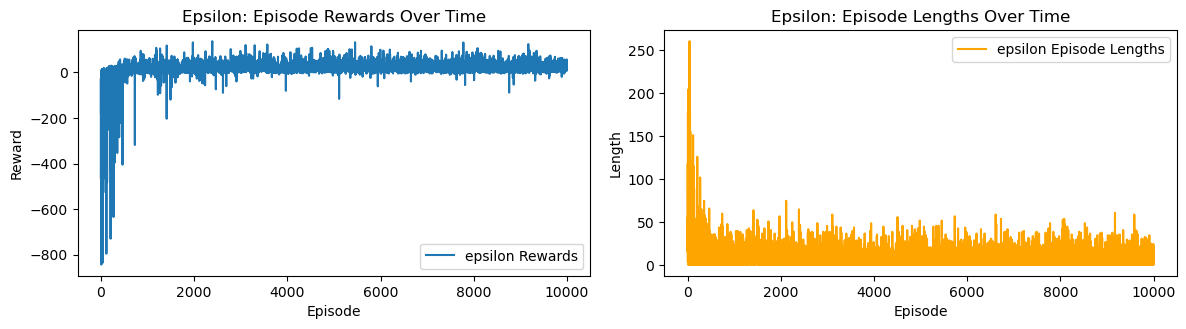


Epsilon Training Completed. Numerical Results:
Average Reward: 16.37
Max Reward: 137.39
Min Reward: -843.85
Average Episode Length: 8.73
Max Episode Length: 260.00
Min Episode Length: 1.00
Training with softmax strategy...


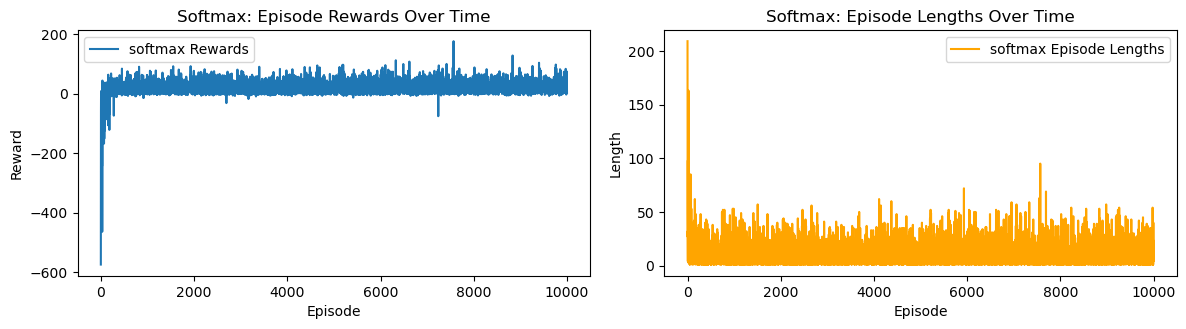


Softmax Training Completed. Numerical Results:
Average Reward: 17.45
Max Reward: 175.77
Min Reward: -574.43
Average Episode Length: 10.35
Max Episode Length: 209.00
Min Episode Length: 1.00
Training with ucb strategy...


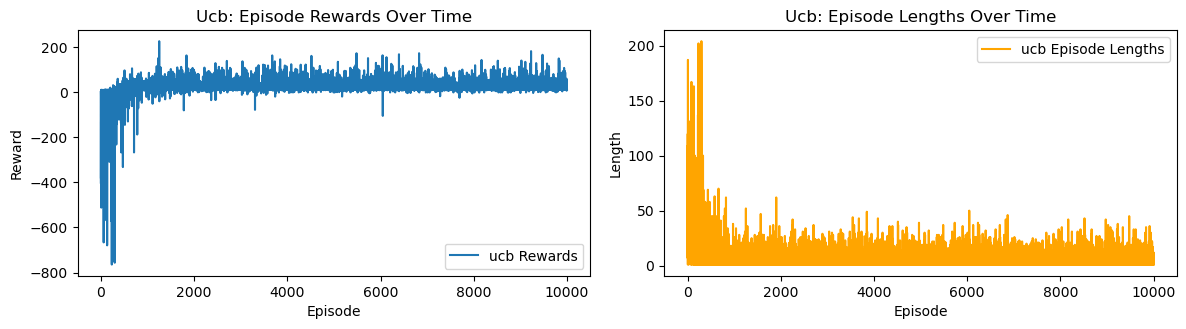


Ucb Training Completed. Numerical Results:
Average Reward: 18.85
Max Reward: 225.21
Min Reward: -764.23
Average Episode Length: 7.18
Max Episode Length: 204.00
Min Episode Length: 1.00


In [22]:
#Exploration and exploitation strategies for double Q-learning

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import seaborn as sns
import os

# Defining the HVAC Environment
class HVACEnvironment:
    def __init__(self, room_size, insulation, hvac_power, external_temp):
        self.room_size = room_size
        self.insulation = insulation
        self.external_temp = external_temp
        self.hvac_power = hvac_power
        self.current_temp = self.external_temp
        self.time_of_day = 0
        self.occupancy_status = 1
        self.temp_bins = np.linspace(15, 30, 10)
        self.time_bins = np.linspace(0, 23, 24)

    def discretize_state(self):
        temp_state = np.digitize(self.current_temp, self.temp_bins) - 1
        time_state = np.digitize(self.time_of_day, self.time_bins) - 1
        return (temp_state, time_state, self.occupancy_status)

    def step(self, action):
        action = max(0, min(action, 4))
        temp_change = (self.hvac_power * (action - 2) - self.insulation * (self.current_temp - self.external_temp))
        self.current_temp += temp_change
        
        target_temp = 22 if self.occupancy_status == 1 else 18
        deviation = abs(self.current_temp - target_temp)
        
        # Adjusting the reward function to reduce the penalty for deviations beyond 1.0 degree
        if deviation < 0.5:
            reward = 10
        elif deviation < 1.0:
            reward = 5
        else:
            reward = -0.25 * (deviation - 1) 

        self.time_of_day = (self.time_of_day + 1) % 24
        self.occupancy_status = random.choice([0, 1])

        discrete_state = self.discretize_state()
        return discrete_state, reward

# Double Q-Learning Agent with Multiple Exploration Strategies
class DoubleQLearning:
    def __init__(self, state_space_dims, action_space_size, alpha=0.1, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64, strategy='epsilon'):
        self.state_space_dims = state_space_dims
        self.action_space_size = action_space_size
        self.q_table1 = np.zeros((*state_space_dims, action_space_size))
        self.q_table2 = np.zeros((*state_space_dims, action_space_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.memory = deque(maxlen=replay_size)
        self.batch_size = batch_size
        self.strategy = strategy
        self.visit_counts = np.zeros((*state_space_dims, action_space_size))  # Using UCB

    def choose_action(self, state):
        if self.strategy == 'epsilon':
            if random.uniform(0, 1) < self.epsilon:
                return random.choice(range(self.action_space_size))  # Exploration
            else:
                q_values = (self.q_table1[state] + self.q_table2[state]) / 2
                return np.argmax(q_values)  # Exploitation
        elif self.strategy == 'softmax':
            q_values = (self.q_table1[state] + self.q_table2[state]) / 2
            exp_q = np.exp(q_values - np.max(q_values))  # Helps to avoid overflow
            probs = exp_q / np.sum(exp_q)
            return np.random.choice(range(self.action_space_size), p=probs)
        elif self.strategy == 'ucb':
            if np.any(self.visit_counts[state] == 0):
                return np.random.choice(range(self.action_space_size))  # For exploring unvisited actions
            total_visits = np.sum(self.visit_counts[state])
            action_visits = self.visit_counts[state]
            q_values = (self.q_table1[state] + self.q_table2[state]) / 2
            ucb_values = q_values + np.sqrt(2 * np.log(total_visits + 1) / (action_visits + 1))
            return np.argmax(ucb_values)
    
    def update_q_table(self, state, action, reward, next_state):
        self.memory.append((state, action, reward, next_state))
        if len(self.memory) >= self.batch_size:
            self.replay_experience()
        self.visit_counts[state][action] += 1  # For updating visit counts

#Double Q-learning works by using 2 Q-tables, it chooses actions from Q-table 1 and computes the target using Q-table 2, and the way it chooses actions from Q-table 2 and  computes the target using Q-table 1
    def replay_experience(self):
        batch = random.sample(self.memory, self.batch_size)
        for state, action, reward, next_state in batch:
            # Choosing an action from Q-table 1
            best_action = np.argmax(self.q_table1[next_state])
            # Computing the target using Q-table 2
            td_target = reward + self.gamma * self.q_table2[next_state][best_action]
            td_error = td_target - self.q_table1[state][action]
            self.q_table1[state][action] += self.alpha * td_error
            
            # Choosing an action from Q-table 2
            best_action = np.argmax(self.q_table2[next_state])
            # Computing the target using Q-table 1
            td_target = reward + self.gamma * self.q_table1[next_state][best_action]
            td_error = td_target - self.q_table2[state][action]
            self.q_table2[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

# Training Function using multiple exploration strategies
def train_agent_double_q(strategy, external_temp, num_episodes=10000):
    state_space_dims = (10, 24, 2)
    action_space_size = 5
    agent = DoubleQLearning(state_space_dims, action_space_size, alpha=0.05, gamma=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01, replay_size=10000, batch_size=64, strategy=strategy)
    env = HVACEnvironment(room_size=50, insulation=0.1, hvac_power=5, external_temp=external_temp)

    episode_rewards = []
    episode_lengths = []

    for episode in range(num_episodes):
        state = env.discretize_state()
        total_reward = 0
        length = 0
        done = False
        while not done:
            action = agent.choose_action(state)
            next_state, reward = env.step(action)
            agent.update_q_table(state, action, reward, next_state)
            state = next_state
            total_reward += reward
            length += 1
            if abs(env.current_temp - (22 if env.occupancy_status == 1 else 18)) < 0.5:
                done = True
        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_lengths.append(length)

    return episode_rewards, episode_lengths, agent.q_table1, agent.q_table2, action_space_size

# For saving and plotting the results
def average_q_table(q_table):
    return np.mean(q_table, axis=-1)

def save_q_tables_as_csv(q_table1, q_table2, season, action_space_size):
    output_directory = r"C:\Users\presi\Downloads\Dissertation2024"
    os.makedirs(output_directory, exist_ok=True)

    avg_q_table1 = average_q_table(q_table1)
    avg_q_table2 = average_q_table(q_table2)

    def save_single_csv(filename, q_table):
        header = "Temp Bin, Time Bin, Average Q-Value"
        with open(filename, 'w') as file:
            file.write(header + '\n')
            for temp_bin in range(q_table.shape[0]):
                for time_bin in range(q_table.shape[1]):
                    q_value = q_table[temp_bin, time_bin]
                    if isinstance(q_value, np.ndarray):
                        q_value = q_value.flatten()[0]
                    if isinstance(q_value, (list, np.ndarray)):
                        print(f"Unexpected q_value type: {type(q_value)} with shape: {np.shape(q_value)}")
                    file.write(f"{temp_bin}, {time_bin}, {q_value:.2f}\n")

    save_single_csv(os.path.join(output_directory, f"{season}_average_q_tableQ1.csv"), avg_q_table1)
    save_single_csv(os.path.join(output_directory, f"{season}_average_q_tableQ2.csv"), avg_q_table2)

def save_q_tables_as_images(q_table1, q_table2, season, action_space_size):
    output_directory = r"C:\Users\presi\Downloads\Dissertation2024"
    os.makedirs(output_directory, exist_ok=True)

    avg_q_table1 = average_q_table(q_table1)
    avg_q_table2 = average_q_table(q_table2)

    for avg_q_table, table_num in [(avg_q_table1, 'Q1'), (avg_q_table2, 'Q2')]:
        plt.figure(figsize=(10, 8))
        sns.heatmap(avg_q_table[:, :, 0], cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
        plt.title(f"Average Q-Table {table_num} Heatmap (Occupancy 0)")
        plt.xlabel('Time Bin')
        plt.ylabel('Temp Bin')
        plt.savefig(os.path.join(output_directory, f"{season}_average_q_table{table_num}_occupancy_0.png"))
        plt.close()

        plt.figure(figsize=(10, 8))
        sns.heatmap(avg_q_table[:, :, 1], cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
        plt.title(f"Average Q-Table {table_num} Heatmap (Occupancy 1)")
        plt.xlabel('Time Bin')
        plt.ylabel('Temp Bin')
        plt.savefig(os.path.join(output_directory, f"{season}_average_q_table{table_num}_occupancy_1.png"))
        plt.close()

# This part of the code is for training and evaluation
strategies = ['epsilon', 'softmax', 'ucb']
results = {}

for strategy in strategies:
    print(f"Training with {strategy} strategy...")
    rewards, lengths, q_table1, q_table2, action_space_size = train_agent_double_q(strategy, external_temp=np.random.uniform(-10, 30))
    results[strategy] = {
        'rewards': rewards,
        'lengths': lengths,
        'q_table1': q_table1,
        'q_table2': q_table2
    }
    save_q_tables_as_csv(q_table1, q_table2, strategy, action_space_size)
    save_q_tables_as_images(q_table1, q_table2, strategy, action_space_size)

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 2, 1)
    plt.plot(rewards, label=f'{strategy} Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title(f'{strategy.capitalize()}: Episode Rewards Over Time')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.plot(lengths, label=f'{strategy} Episode Lengths', color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Length')
    plt.title(f'{strategy.capitalize()}: Episode Lengths Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Printing numerical results
    print(f"\n{strategy.capitalize()} Training Completed. Numerical Results:")
    print(f"Average Reward: {np.mean(rewards):.2f}")
    print(f"Max Reward: {np.max(rewards):.2f}")
    print(f"Min Reward: {np.min(rewards):.2f}")
    print(f"Average Episode Length: {np.mean(lengths):.2f}")
    print(f"Max Episode Length: {np.max(lengths):.2f}")
    print(f"Min Episode Length: {np.min(lengths):.2f}")
